In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### KMeans function:

In [ ]:
def kmeans_numpy(X, k, max_iters=100, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Initialize centroids
    random_indices = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_indices].copy()

    for _ in range(max_iters):
        # broadcasting each point to each centroids
        distance = np.sqrt((X[:, np.newaxis, :] - centroids) ** 2).sum(axis=2)
        # closed distance between each point and all centroids
        labels = np.argmin(distance, axis=1)

        # update centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if (labels == i).sum() > 0
            else centroids[i]
            for i in range(k)
        ])

        # if all data points are very close (1e-8 on default), then break loop before the max_iters
        # otherwise a
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

### Sample Data

In [10]:
# 5 data points in 2D space
X = np.array([
    [0, 0],
    [1, 1],
    [5, 5],
    [6, 6],
    [10, 10]
])

# 2 cluster centroids
centroids = np.array([
    [0.5, 0.5],  # Near the origin
    [6, 6]       # Near the top-right
])

In [12]:
labels, centroids = kmeans_numpy(X, 2, max_iters=10, random_state=42)

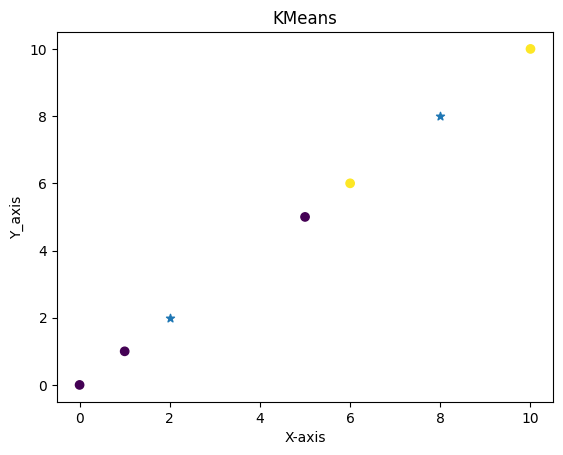

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:,1], marker='*')
plt.xlabel('X-axis')
plt.ylabel('Y_axis')
plt.title('KMeans')
plt.show()